In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

In [8]:
df = pd.read_csv("../cluster/heart.csv")
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [9]:
df_cleaned = df.dropna()
df_cleaned = df_cleaned.drop_duplicates()
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

Original shape: (1025, 14)
Cleaned shape: (302, 14)


/var/folders/nw/c745mgyj79lf4r0gkq4qslmr0000gn/T/ipykernel_6953/1886883051.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='sex', palette='Set2')


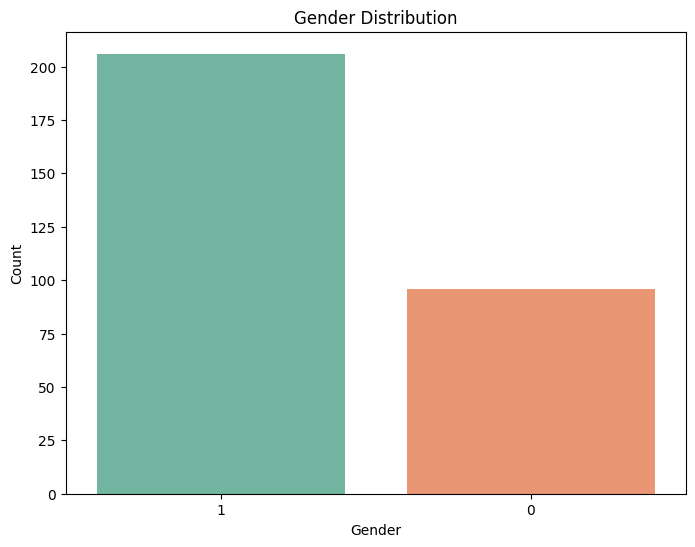

In [13]:
# Gender distribution 
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='sex', palette='Set2')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


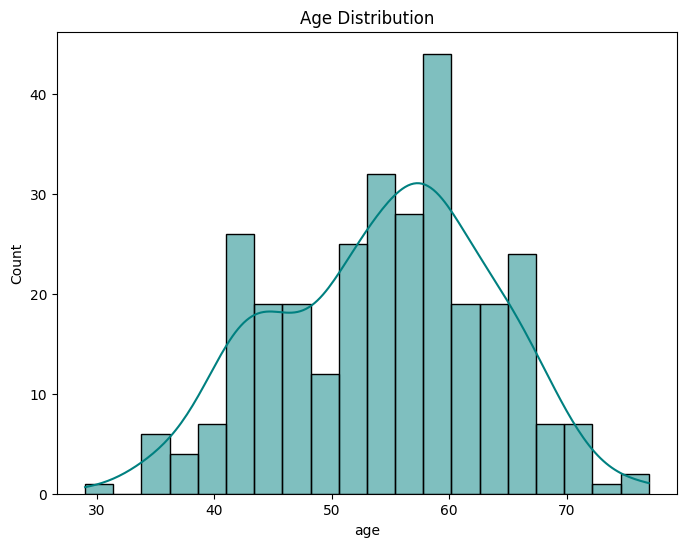

In [16]:
# Age Distribution 
plt.figure(figsize=(8, 6))
sns.histplot(df_cleaned['age'], bins=20, kde=True, color='teal')
plt.title('Age Distribution')
plt.show()

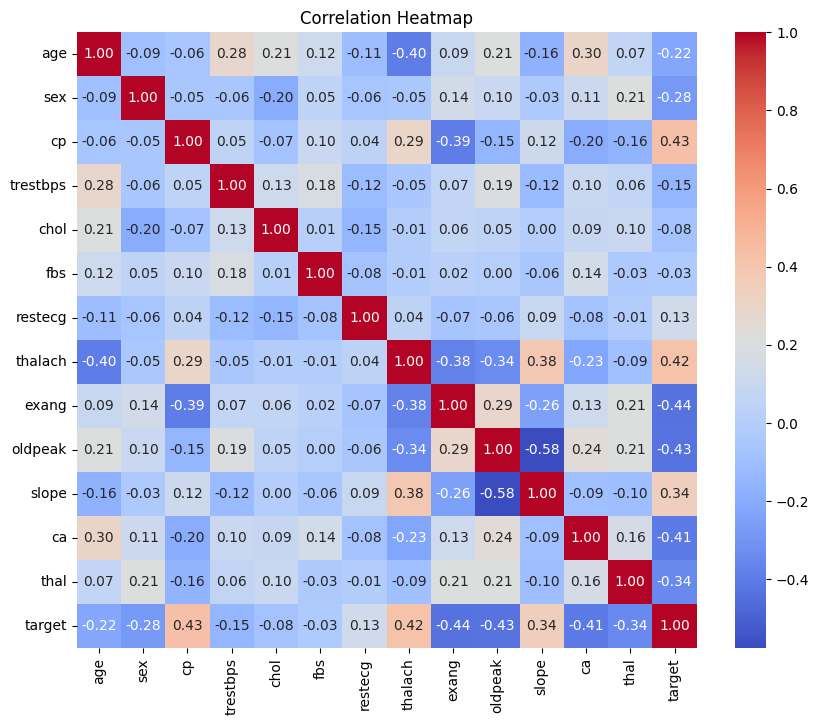

In [17]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
# Data Transformation
# Removing the ground truth target for unsupervised learning
X = df_cleaned.drop('target', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

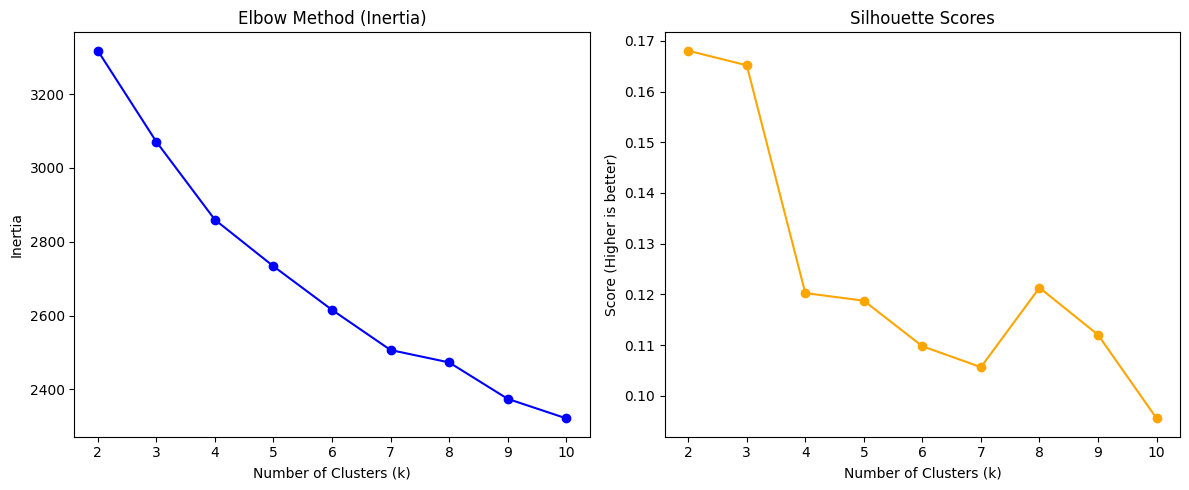

Best number of clusters based on Silhouette scores: 2
Best number of clusters based on Elbow method: 10


In [30]:
# Test a range of clusters to find the best 'k'
range_n_clusters = range(2, 11)
inertia = []
silhouette_scores = []

for n in range_n_clusters:
    # K-Means for metrics
    km = KMeans(n_clusters=n, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Diagnostic Charts
plt.figure(figsize=(12, 5))

# Elbow Plot
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o', color='blue')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

# Silhouette Plot
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', color='orange')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score (Higher is better)")

plt.tight_layout()
plt.show()

#choose best_k
# Choose the best k (based on max silhouette score and min inertia)
best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
best_k_elbow = range_n_clusters[inertia.index(min(inertia))]  # Use min here

print(f"Best number of clusters based on Silhouette scores: {best_k}")
print(f"Best number of clusters based on Elbow method: {best_k_elbow}")

--- Results for k = 2 ---
K-Means Silhouette: 0.1681


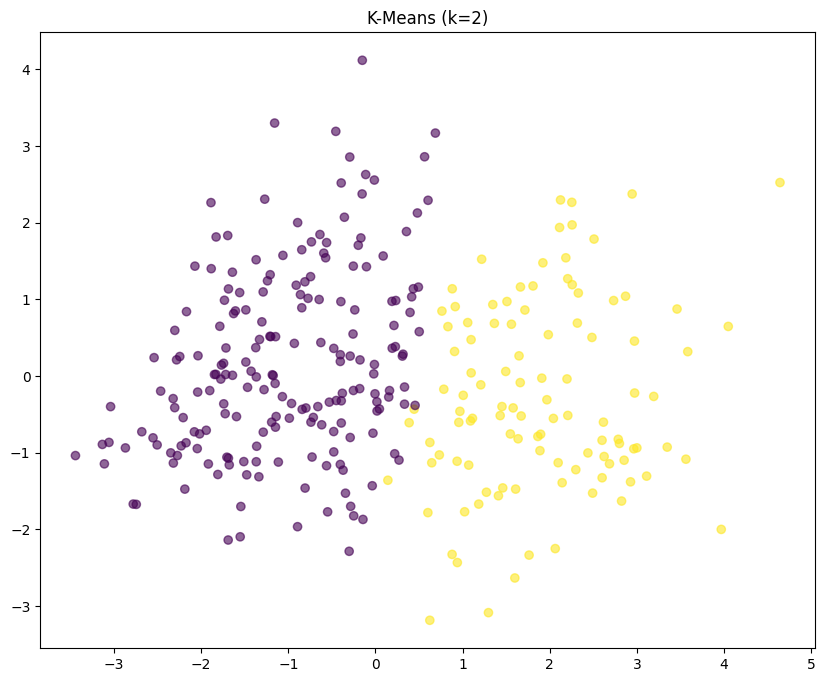

In [36]:
best_k=2

# Initialize Models
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Fit and Predict
df_cleaned['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

# Evaluation
print(f"--- Results for k = {best_k} ---")
print(f"K-Means Silhouette: {silhouette_score(X_scaled, df_cleaned['kmeans_cluster']):.4f}")

# Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# Plot K-Means
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cleaned['kmeans_cluster'], cmap='viridis', alpha=0.6)
plt.title(f'K-Means (k={best_k})')
plt.show()

--- Results for k = 2 ---
Agglomerative Silhouette: 0.1437


<Figure size 1400x600 with 0 Axes>

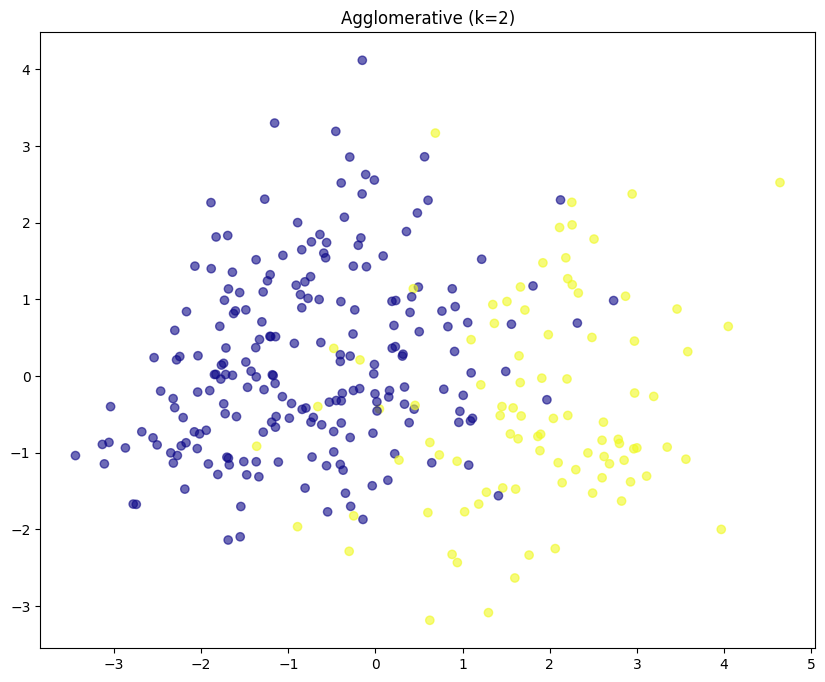

In [ ]:
best_k=2

# Initialize Model
agg_final = AgglomerativeClustering(n_clusters=best_k)

# Fit and Predict
df_cleaned['agg_cluster'] = agg_final.fit_predict(X_scaled)

# Evaluation
print(f"--- Results for k = {best_k} ---")
print(f"Agglomerative Silhouette: {silhouette_score(X_scaled, df_cleaned['agg_cluster']):.4f}")

# Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# Plot Agglomerative
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cleaned['agg_cluster'], cmap='plasma', alpha=0.6)
plt.title(f'Agglomerative (k={best_k})')

plt.show()

In [42]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_score, completeness_score
import pandas as pd

# 1. Create an Evaluation Function
def evaluate_clustering(labels, name):
    print(f"--- {name} Evaluation ---")
    
    # Internal Evaluation: Silhouette (No target needed)
    sil = silhouette_score(X_scaled, labels)
    
    # External Evaluation: Comparing against 'target' ground truth
    ari = adjusted_rand_score(df_cleaned['target'], labels)
    hom = homogeneity_score(df_cleaned['target'], labels)
    comp = completeness_score(df_cleaned['target'], labels)
    
    print(f"Silhouette Score (Internal): {sil:.4f}")
    print(f"Adjusted Rand Index (External): {ari:.4f}")
    print(f"Homogeneity (Do clusters contain 1 class?): {hom:.4f}")
    print(f"Completeness (Are all class members together?): {comp:.4f}\n")
    
    return [sil, ari, hom, comp]

# 2. Run Evaluation for both models
km_results = evaluate_clustering(df_cleaned['kmeans_cluster'], "K-Means")
agg_results = evaluate_clustering(df_cleaned['agg_cluster'], "Agglomerative")

# 3. Cluster-to-Target Mapping (Mapping "Unsupervised" to "Reality")
# This helps see if Cluster 0 is the "Healthy" group and Cluster 1 is the "Sick" group
print("K-Means Cluster vs. Actual Target (Crosstab):")
print(pd.crosstab(df_cleaned['target'], df_cleaned['kmeans_cluster'], 
                  rownames=['Actual Target'], colnames=['K-Means Cluster']))

--- K-Means Evaluation ---
Silhouette Score (Internal): 0.1681
Adjusted Rand Index (External): 0.3936
Homogeneity (Do clusters contain 1 class?): 0.3189
Completeness (Are all class members together?): 0.3393

--- Agglomerative Evaluation ---
Silhouette Score (Internal): 0.1437
Adjusted Rand Index (External): 0.2372
Homogeneity (Do clusters contain 1 class?): 0.1907
Completeness (Are all class members together?): 0.2148

K-Means Cluster vs. Actual Target (Crosstab):
K-Means Cluster    0   1
Actual Target           
0                 44  94
1                152  12
